# Phát hiện hành vi bất thường của người dùng trên website thương mại điện tử

## RetailRocket E-Commerce Dataset

Notebook này xử lý bài toán theo hướng **session-level anomaly detection**: mỗi dòng sau xử lý tương ứng với **một phiên truy cập** của người dùng, thay vì gom toàn bộ lịch sử theo `visitorid`.

**Ý tưởng chính:**

1. Đọc 4 file của RetailRocket: `events.csv`, `item_properties_part1.csv`, `item_properties_part2.csv`, `category_tree.csv`.
2. Tiền xử lý dữ liệu sự kiện, chuyển `timestamp` sang ngày giờ.
3. Tạo `session_id` theo khoảng cách 30 phút giữa hai sự kiện liên tiếp.
4. Trích xuất đặc trưng hành vi theo phiên truy cập.
5. Tạo nhãn bất thường bằng luật nghiệp vụ vì dataset không có nhãn thật.
6. Huấn luyện mô hình phân loại bình thường/bất thường và so sánh với mô hình không giám sát.

> Lưu ý: `is_anomaly_rule` là nhãn tham chiếu do luật nghiệp vụ tạo ra, không phải nhãn gian lận thật. Vì vậy kết quả mô hình thể hiện mức độ học và khái quát hóa theo nhãn luật, không khẳng định tuyệt đối rằng một phiên là gian lận ngoài thực tế.

## 1. Import thư viện và cấu hình

In [1]:
from pathlib import Path
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from IPython.display import display

from sklearn.cluster import KMeans
from sklearn.dummy import DummyClassifier
from sklearn.ensemble import IsolationForest, RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    average_precision_score,
    classification_report,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
)
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import RobustScaler
from sklearn.tree import DecisionTreeClassifier, plot_tree

try:
    from xgboost import XGBClassifier
    HAS_XGBOOST = True
except Exception:
    HAS_XGBOOST = False

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 120)
pd.set_option("display.width", 160)

RANDOM_STATE = 42
SESSION_GAP_MINUTES = 30
MAX_SUPERVISED_ROWS = 300_000
MAX_UNSUPERVISED_ROWS = 250_000

OUTPUT_DIR = Path("outputs")
OUTPUT_DIR.mkdir(exist_ok=True)

## 2. Xác định đường dẫn và đọc dữ liệu

Notebook tự dò dữ liệu ở các vị trí phổ biến:

- Thư mục hiện tại.
- `/kaggle/input/ecommerce-dataset`.
- `/content` nếu chạy trên Google Colab.

File bắt buộc là `events.csv`. Ba file còn lại dùng để bổ sung thông tin sản phẩm và danh mục.

In [2]:
def find_data_dir():
    candidates = [
        Path("."),
        Path("./data"),
        Path("/kaggle/input/ecommerce-dataset"),
        Path("/content"),
        Path("/content/ecommerce-dataset"),
    ]
    for path in candidates:
        if (path / "events.csv").exists():
            return path
    raise FileNotFoundError(
        "Không tìm thấy events.csv. Hãy đặt events.csv cùng thư mục notebook hoặc sửa biến DATA_DIR."
    )

DATA_DIR = find_data_dir()
print("DATA_DIR =", DATA_DIR.resolve())

EVENTS_PATH = DATA_DIR / "events.csv"
ITEM_PROP_1_PATH = DATA_DIR / "item_properties_part1.csv"
ITEM_PROP_2_PATH = DATA_DIR / "item_properties_part2.csv"
CATEGORY_TREE_PATH = DATA_DIR / "category_tree.csv"

events = pd.read_csv(EVENTS_PATH)

item_properties_part1 = pd.read_csv(ITEM_PROP_1_PATH) if ITEM_PROP_1_PATH.exists() else None
item_properties_part2 = pd.read_csv(ITEM_PROP_2_PATH) if ITEM_PROP_2_PATH.exists() else None
category_tree = pd.read_csv(CATEGORY_TREE_PATH) if CATEGORY_TREE_PATH.exists() else None

print("events shape:", events.shape)
if item_properties_part1 is not None:
    print("item_properties_part1 shape:", item_properties_part1.shape)
if item_properties_part2 is not None:
    print("item_properties_part2 shape:", item_properties_part2.shape)
if category_tree is not None:
    print("category_tree shape:", category_tree.shape)

DATA_DIR = /Users/tuna/Code/DAKPDL2/data
events shape: (2756101, 5)
item_properties_part1 shape: (10999999, 4)
item_properties_part2 shape: (9275903, 4)
category_tree shape: (1669, 2)


## 3. Khám phá nhanh cấu trúc 4 file

In [3]:
def show_basic_info(name, df):
    if df is None:
        print(f"{name}: không có file")
        return
    print("=" * 80)
    print(name)
    print("Shape:", df.shape)
    display(df.head())
    info_df = pd.DataFrame({
        "column": df.columns,
        "dtype": [df[c].dtype for c in df.columns],
        "missing": [df[c].isna().sum() for c in df.columns],
        "missing_percent": [df[c].isna().mean() * 100 for c in df.columns],
        "n_unique": [df[c].nunique(dropna=True) for c in df.columns],
    })
    display(info_df)

show_basic_info("events.csv", events)
show_basic_info("item_properties_part1.csv", item_properties_part1)
show_basic_info("item_properties_part2.csv", item_properties_part2)
show_basic_info("category_tree.csv", category_tree)

events.csv
Shape: (2756101, 5)


,timestamp,visitorid,event,itemid,transactionid
0,1433221332117,257597,view,355908,NaN
1,1433224214164,992329,view,248676,NaN
2,1433221999827,111016,view,318965,NaN
3,1433221955914,483717,view,253185,NaN
4,1433221337106,951259,view,367447,NaN


,column,dtype,missing,missing_percent,n_unique
0,timestamp,int64,0,0.00000,2750455
1,visitorid,int64,0,0.00000,1407580
2,event,str,0,0.00000,3
3,itemid,int64,0,0.00000,235061
4,transactionid,float64,2733644,99.18519,17672


item_properties_part1.csv
Shape: (10999999, 4)


,timestamp,itemid,property,value
0,1435460400000,460429,categoryid,1338
1,1441508400000,206783,888,1116713 960601 n277.200
2,1439089200000,395014,400,n552.000 639502 n720.000 424566
3,1431226800000,59481,790,n15360.000
4,1431831600000,156781,917,828513


...

,timestamp,itemid,property,value
0,1433041200000,183478,561,769062
1,1439694000000,132256,976,n26.400 1135780
2,1435460400000,420307,921,1149317 1257525
3,1431831600000,403324,917,1204143
4,1435460400000,230701,521,769062


,column,dtype,missing,missing_percent,n_unique
0,timestamp,int64,0,0.0,18
1,itemid,int64,0,0.0,417053
2,property,str,0,0.0,1094
3,value,str,0,0.0,1075730


category_tree.csv
Shape: (1669, 2)


,categoryid,parentid
0,1016,213.0
1,809,169.0
2,570,9.0
3,1691,885.0
4,536,1691.0


,column,dtype,missing,missing_percent,n_unique
0,categoryid,int64,0,0.000000,1669
1,parentid,float64,25,1.497903,362


## 4. Tiền xử lý `events.csv`

Các bước xử lý chính:

- Xóa dòng trùng lặp.
- Giữ lại các event hợp lệ: `view`, `addtocart`, `transaction`.
- Chuyển `timestamp` từ Unix timestamp mili giây sang ngày giờ.
- Tạo thêm các thuộc tính thời gian: `date`, `hour`, `dayofweek`, `is_night`.
- Sắp xếp theo `visitorid` và thời gian.

In [4]:
required_cols = {"timestamp", "visitorid", "event", "itemid", "transactionid"}
missing_cols = required_cols.difference(events.columns)
if missing_cols:
    raise ValueError(f"Thiếu cột bắt buộc trong events.csv: {sorted(missing_cols)}")

before_rows = len(events)
events = events.drop_duplicates()
print(f"Số dòng trùng lặp đã xóa: {before_rows - len(events):,}")

events = events.dropna(subset=["timestamp", "visitorid", "event", "itemid"])
events = events[events["event"].isin(["view", "addtocart", "transaction"])].copy()

events["timestamp"] = pd.to_numeric(events["timestamp"], errors="coerce")
events = events.dropna(subset=["timestamp"])
events["timestamp"] = events["timestamp"].astype("int64")

events["datetime"] = pd.to_datetime(events["timestamp"], unit="ms")
events["date"] = events["datetime"].dt.date
events["hour"] = events["datetime"].dt.hour
events["dayofweek"] = events["datetime"].dt.dayofweek
events["is_night"] = ((events["hour"] >= 0) & (events["hour"] <= 5)).astype(int)

events = events.sort_values(["visitorid", "timestamp"]).reset_index(drop=True)

print(f"Tổng số sự kiện sau tiền xử lý: {len(events):,}")
print(f"Số visitor duy nhất: {events['visitorid'].nunique():,}")
print(f"Số item duy nhất: {events['itemid'].nunique():,}")
print(f"Khoảng thời gian dữ liệu: {events['datetime'].min()} -> {events['datetime'].max()}")

display(events.head())

Số dòng trùng lặp đã xóa: 460
Tổng số sự kiện sau tiền xử lý: 2,755,641
Số visitor duy nhất: 1,407,580
Số item duy nhất: 235,061
Khoảng thời gian dữ liệu: 2015-05-03 03:00:04.384000 -> 2015-09-18 02:59:47.788000


,timestamp,visitorid,event,itemid,transactionid,datetime,date,hour,dayofweek,is_night
0,1442004589439,0,view,285930,NaN,2015-09-11 20:49:49.439,2015-09-11,20,4,0
1,1442004759591,0,view,357564,NaN,2015-09-11 20:52:39.591,2015-09-11,20,4,0
2,1442004917175,0,view,67045,NaN,2015-09-11 20:55:17.175,2015-09-11,20,4,0
3,1439487966444,1,view,72028,NaN,2015-08-13 17:46:06.444,2015-08-13,17,3,0
4,1438969904567,2,view,325215,NaN,2015-08-07 17:51:44.567,2015-08-07,17,4,0


## 5. Tạo phiên truy cập `session_id`

Quy ước: nếu hai sự kiện liên tiếp của cùng một `visitorid` cách nhau quá **30 phút**, sự kiện sau được xem là bắt đầu một phiên mới.

Việc chuyển sang phân tích theo phiên giúp tránh nhầm lẫn giữa hành vi dài hạn của một người dùng và hành vi bất thường trong một lần truy cập cụ thể.

In [5]:
events["prev_timestamp"] = events.groupby("visitorid")["timestamp"].shift(1)
events["time_diff_sec_global"] = (events["timestamp"] - events["prev_timestamp"]) / 1000

events["new_session"] = (
    events["time_diff_sec_global"].isna() |
    (events["time_diff_sec_global"] > SESSION_GAP_MINUTES * 60)
)

events["session_id"] = events.groupby("visitorid")["new_session"].cumsum().astype("int32")

# Tính lại khoảng cách thời gian trong từng phiên để tránh lấy khoảng cách giữa hai phiên khác nhau.
events["prev_timestamp_in_session"] = events.groupby(["visitorid", "session_id"])["timestamp"].shift(1)
events["time_diff_sec"] = (events["timestamp"] - events["prev_timestamp_in_session"]) / 1000

print(f"Tổng số phiên truy cập: {events[['visitorid', 'session_id']].drop_duplicates().shape[0]:,}")
print("Số phiên trung bình mỗi visitor:", round(events.groupby("visitorid")["session_id"].nunique().mean(), 3))

display(events[["visitorid", "session_id", "datetime", "event", "itemid", "time_diff_sec"]].head(10))

Tổng số phiên truy cập: 1,761,675
Số phiên trung bình mỗi visitor: 1.252


,visitorid,session_id,datetime,event,itemid,time_diff_sec
0,0,1,2015-09-11 20:49:49.439,view,285930,NaN
1,0,1,2015-09-11 20:52:39.591,view,357564,170.152
2,0,1,2015-09-11 20:55:17.175,view,67045,157.584
3,1,1,2015-08-13 17:46:06.444,view,72028,NaN
4,2,1,2015-08-07 17:51:44.567,view,325215,NaN
5,2,1,2015-08-07 17:53:33.790,view,325215,109.223
6,2,1,2015-08-07 17:56:52.664,view,259884,198.874
7,2,1,2015-08-07 18:01:08.920,view,216305,256.256
8,2,1,2015-08-07 18:08:25.669,view,342816,436.749
9,2,1,2015-08-07 18:17:24.375,view,342816,538.706


## 6. Khám phá dữ liệu sự kiện sau khi tạo phiên

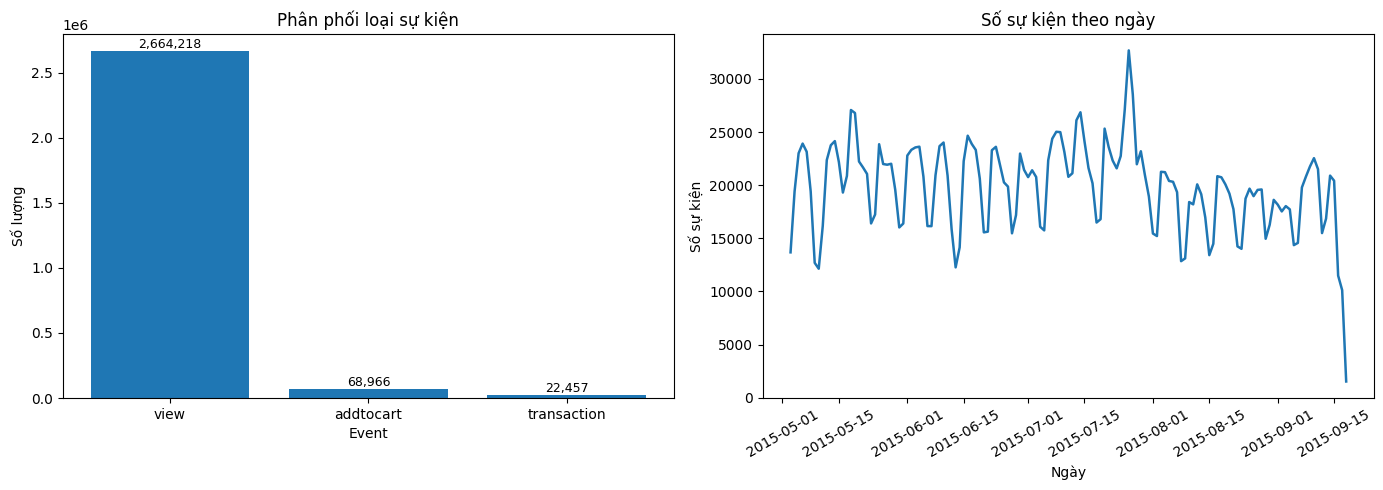

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

event_counts = events["event"].value_counts()
axes[0].bar(event_counts.index, event_counts.values)
axes[0].set_title("Phân phối loại sự kiện")
axes[0].set_xlabel("Event")
axes[0].set_ylabel("Số lượng")
for i, v in enumerate(event_counts.values):
    axes[0].text(i, v, f"{v:,}", ha="center", va="bottom", fontsize=9)

by_day = events.groupby("date").size()
axes[1].plot(pd.to_datetime(by_day.index), by_day.values, linewidth=1.8)
axes[1].set_title("Số sự kiện theo ngày")
axes[1].set_xlabel("Ngày")
axes[1].set_ylabel("Số sự kiện")
axes[1].tick_params(axis="x", rotation=30)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / "01_event_distribution.png", dpi=160, bbox_inches="tight")
plt.show()

## 7. Tạo bảng đặc trưng hành vi theo phiên

Bảng `session_features` là bảng chính để tạo nhãn và huấn luyện mô hình. Mỗi dòng tương ứng với một cặp `(visitorid, session_id)`.

In [7]:
group_cols = ["visitorid", "session_id"]

session_features = events.groupby(group_cols).agg(
    total_events=("event", "count"),
    unique_items=("itemid", "nunique"),
    active_hours=("hour", "nunique"),
    session_start=("datetime", "min"),
    session_end=("datetime", "max"),
    n_view=("event", lambda x: (x == "view").sum()),
    n_addtocart=("event", lambda x: (x == "addtocart").sum()),
    n_transaction=("event", lambda x: (x == "transaction").sum()),
    night_events=("is_night", "sum"),
    min_interval_sec=("time_diff_sec", "min"),
    mean_interval_sec=("time_diff_sec", "mean"),
    median_interval_sec=("time_diff_sec", "median"),
    max_interval_sec=("time_diff_sec", "max"),
).reset_index()

session_features["session_duration_sec"] = (
    session_features["session_end"] - session_features["session_start"]
).dt.total_seconds()

session_features["events_per_minute"] = (
    session_features["total_events"] / (session_features["session_duration_sec"] / 60 + 1)
)

session_features["view_rate"] = session_features["n_view"] / session_features["total_events"].clip(lower=1)
session_features["atc_rate"] = session_features["n_addtocart"] / session_features["total_events"].clip(lower=1)
session_features["buy_rate"] = session_features["n_transaction"] / session_features["total_events"].clip(lower=1)
session_features["night_ratio"] = session_features["night_events"] / session_features["total_events"].clip(lower=1)
session_features["view_to_cart_ratio"] = session_features["n_view"] / (session_features["n_addtocart"] + 1)
session_features["cart_to_transaction_ratio"] = session_features["n_addtocart"] / (session_features["n_transaction"] + 1)

# Các phiên chỉ có một sự kiện sẽ không có khoảng cách thời gian giữa hai event.
for col in ["min_interval_sec", "mean_interval_sec", "median_interval_sec", "max_interval_sec"]:
    session_features[col] = session_features[col].fillna(0)

print("session_features shape:", session_features.shape)
display(session_features.head())

session_features shape: (1761675, 23)


,visitorid,session_id,total_events,unique_items,active_hours,session_start,session_end,n_view,n_addtocart,n_transaction,night_events,min_interval_sec,mean_interval_sec,median_interval_sec,max_interval_sec,session_duration_sec,events_per_minute,view_rate,atc_rate,buy_rate,night_ratio,view_to_cart_ratio,cart_to_transaction_ratio
0,0,1,3,3,1,2015-09-11 20:49:49.439,2015-09-11 20:55:17.175,3,0,0,0,157.584,163.868000,163.868,170.152,327.736,0.464233,1.0,0.0,0.0,0.0,3.0,0.0
1,1,1,1,1,1,2015-08-13 17:46:06.444,2015-08-13 17:46:06.444,1,0,0,0,0.000,0.000000,0.000,0.000,0.000,1.000000,1.0,0.0,0.0,0.0,1.0,0.0
2,2,1,8,4,2,2015-08-07 17:51:44.567,2015-08-07 18:20:57.845,8,0,0,0,18.795,250.468286,198.874,538.706,1753.278,0.264714,1.0,0.0,0.0,0.0,8.0,0.0
3,3,1,1,1,1,2015-08-01 07:10:35.296,2015-08-01 07:10:35.296,1,0,0,0,0.000,0.000000,0.000,0.000,0.000,1.000000,1.0,0.0,0.0,0.0,1.0,0.0
4,4,1,1,1,1,2015-09-15 21:24:27.167,2015-09-15 21:24:27.167,1,0,0,0,0.000,0.000000,0.000,0.000,0.000,1.000000,1.0,0.0,0.0,0.0,1.0,0.0


## 8. Tạo đặc trưng lặp sản phẩm trong phiên

Các đặc trưng này dùng để phát hiện:

- `Item hoarding`: thêm cùng sản phẩm vào giỏ quá nhiều lần.
- `Repeated view spam`: xem lặp lại cùng sản phẩm quá nhiều lần.

In [8]:
view_repeat = (
    events[events["event"] == "view"]
    .groupby(["visitorid", "session_id", "itemid"])
    .size()
    .reset_index(name="same_item_view_count")
)

cart_repeat = (
    events[events["event"] == "addtocart"]
    .groupby(["visitorid", "session_id", "itemid"])
    .size()
    .reset_index(name="same_item_cart_count")
)

max_same_item_view = (
    view_repeat.groupby(["visitorid", "session_id"])["same_item_view_count"]
    .max()
    .reset_index(name="max_same_item_view")
)

max_same_item_atc = (
    cart_repeat.groupby(["visitorid", "session_id"])["same_item_cart_count"]
    .max()
    .reset_index(name="max_same_item_atc")
)

session_features = session_features.merge(max_same_item_view, on=group_cols, how="left")
session_features = session_features.merge(max_same_item_atc, on=group_cols, how="left")
session_features[["max_same_item_view", "max_same_item_atc"]] = session_features[["max_same_item_view", "max_same_item_atc"]].fillna(0)

print("Đã thêm max_same_item_view và max_same_item_atc")
display(session_features[["visitorid", "session_id", "max_same_item_view", "max_same_item_atc"]].head())

Đã thêm max_same_item_view và max_same_item_atc


,visitorid,session_id,max_same_item_view,max_same_item_atc
0,0,1,1.0,0.0
1,1,1,1.0,0.0
2,2,1,3.0,0.0
3,3,1,1.0,0.0
4,4,1,1.0,0.0


## 9. Bổ sung thông tin danh mục sản phẩm từ 3 file còn lại

Phần này dùng `item_properties_part1.csv`, `item_properties_part2.csv` và `category_tree.csv` để tạo thêm đặc trưng:

- `unique_categories`: số danh mục sản phẩm khác nhau trong phiên.
- `unique_parent_categories`: số danh mục cha khác nhau trong phiên.

Nếu thiếu các file này, notebook vẫn chạy được với riêng `events.csv`.

In [9]:
use_category_features = item_properties_part1 is not None and item_properties_part2 is not None

if use_category_features:
    item_properties = pd.concat([item_properties_part1, item_properties_part2], ignore_index=True)
    item_category = item_properties[item_properties["property"] == "categoryid"][["timestamp", "itemid", "value"]].copy()
    item_category = item_category.rename(columns={"value": "categoryid"})
    item_category["categoryid"] = pd.to_numeric(item_category["categoryid"], errors="coerce")
    item_category = item_category.dropna(subset=["categoryid"])
    item_category["categoryid"] = item_category["categoryid"].astype("int64")

    # Một item có thể có nhiều category theo thời gian, lấy bản ghi mới nhất để đơn giản hóa.
    item_category = (
        item_category.sort_values(["itemid", "timestamp"])
        .drop_duplicates(subset=["itemid"], keep="last")
        [["itemid", "categoryid"]]
    )

    events = events.merge(item_category, on="itemid", how="left")

    if category_tree is not None:
        category_tree_clean = category_tree.copy()
        category_tree_clean["categoryid"] = pd.to_numeric(category_tree_clean["categoryid"], errors="coerce")
        category_tree_clean["parentid"] = pd.to_numeric(category_tree_clean["parentid"], errors="coerce")
        events = events.merge(category_tree_clean, on="categoryid", how="left")
    else:
        events["parentid"] = np.nan

    category_features = events.groupby(group_cols).agg(
        unique_categories=("categoryid", "nunique"),
        unique_parent_categories=("parentid", "nunique"),
    ).reset_index()

    session_features = session_features.merge(category_features, on=group_cols, how="left")
    session_features[["unique_categories", "unique_parent_categories"]] = (
        session_features[["unique_categories", "unique_parent_categories"]].fillna(0)
    )
else:
    session_features["unique_categories"] = 0
    session_features["unique_parent_categories"] = 0

print("use_category_features =", use_category_features)
display(session_features[["visitorid", "session_id", "unique_categories", "unique_parent_categories"]].head())

use_category_features = True


,visitorid,session_id,unique_categories,unique_parent_categories
0,0,1,3,2
1,1,1,1,1
2,2,1,2,1
3,3,1,1,1
4,4,1,0,0


## 10. Phân tích phân phối đặc trưng trước khi tạo luật

Các ngưỡng bất thường không nên chọn hoàn toàn cảm tính. Notebook này dùng kết hợp:

- Ý nghĩa nghiệp vụ.
- Phân phối dữ liệu, đặc biệt là nhóm nằm ở phần đuôi như top 1% hoặc top 0.5%.

Thống kê các đặc trưng chính theo phiên:


,count,mean,std,min,50%,75%,90%,95%,99%,99.5%,max
total_events,1761675.0,1.564216,2.599172,1.00000,1.0,1.0,2.0,4.00000,9.000000,13.00000,417.000000
unique_items,1761675.0,1.332739,1.784379,1.00000,1.0,1.0,2.0,3.00000,6.000000,9.00000,389.000000
events_per_minute,1761675.0,0.963034,0.292319,0.04761,1.0,1.0,1.0,1.27278,1.894396,2.08656,20.723997
n_view,1761675.0,1.512321,2.352375,0.00000,1.0,1.0,2.0,4.00000,8.000000,12.00000,417.000000
n_addtocart,1761675.0,0.039148,0.397012,0.00000,0.0,0.0,0.0,0.00000,1.000000,2.00000,114.000000
n_transaction,1761675.0,0.012748,0.207124,0.00000,0.0,0.0,0.0,0.00000,0.000000,1.00000,59.000000
night_ratio,1761675.0,0.310657,0.462177,0.00000,0.0,1.0,1.0,1.00000,1.000000,1.00000,1.000000
max_same_item_view,1761675.0,1.153889,0.565742,0.00000,1.0,1.0,2.0,2.00000,3.000000,4.00000,59.000000
max_same_item_atc,1761675.0,0.027457,0.190257,0.00000,0.0,0.0,0.0,0.00000,1.000000,1.00000,31.000000
unique_categories,1761675.0,0.961504,0.884045,0.00000,1.0,1.0,1.0,1.00000,3.000000,4.00000,113.000000


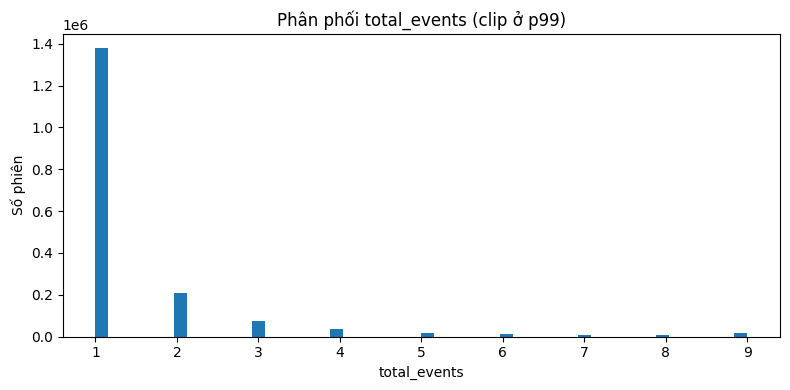

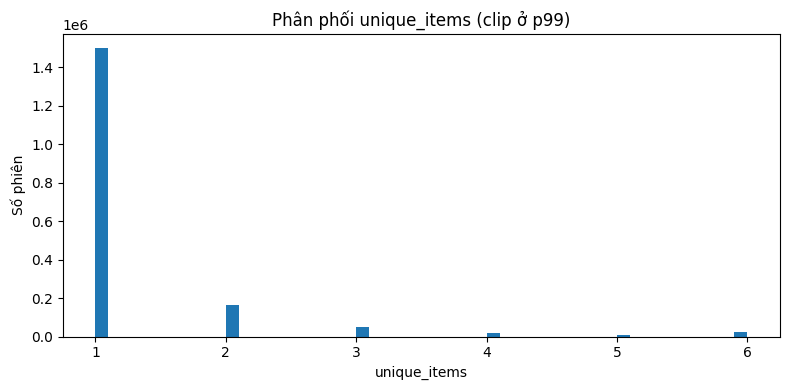

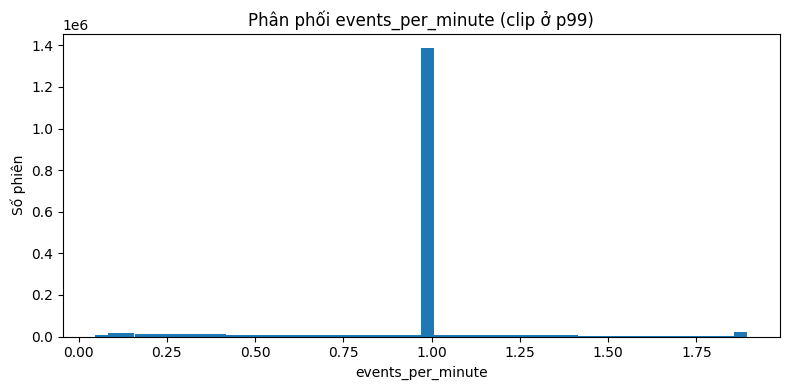

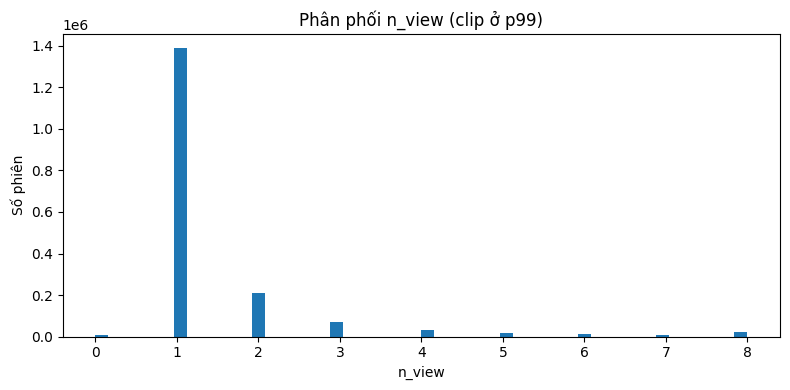

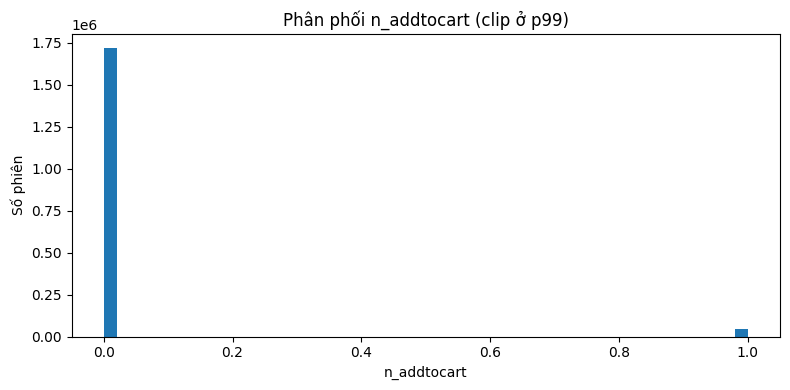

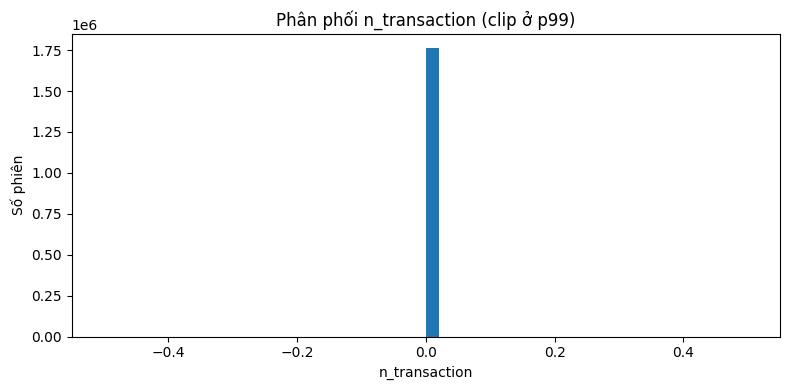

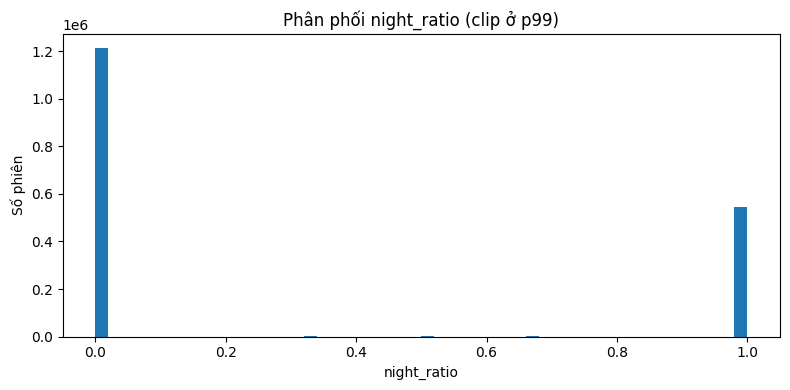

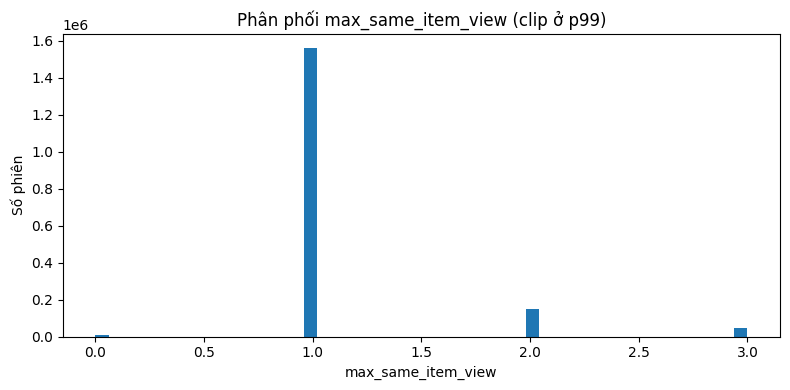

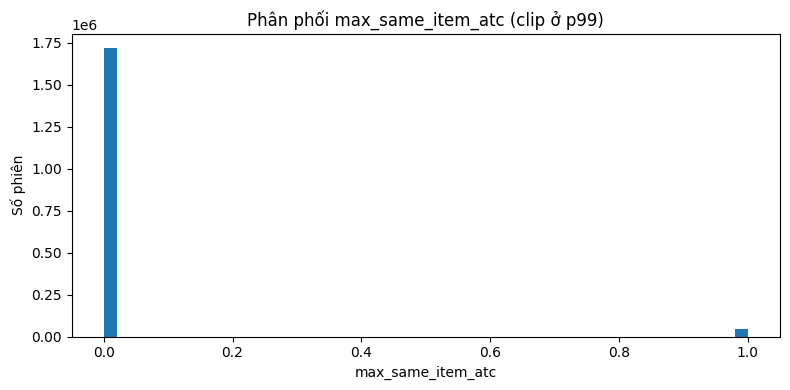

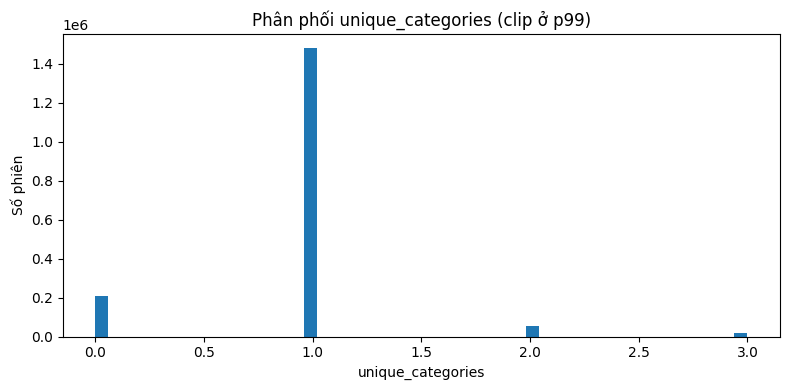

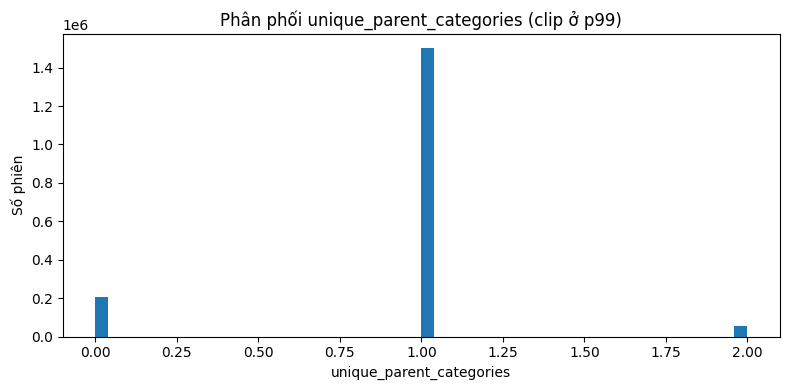

In [10]:
important_cols = [
    "total_events", "unique_items", "events_per_minute", "n_view", "n_addtocart",
    "n_transaction", "night_ratio", "max_same_item_view", "max_same_item_atc",
    "unique_categories", "unique_parent_categories"
]

profile_summary = session_features[important_cols].describe(percentiles=[0.5, 0.75, 0.9, 0.95, 0.99, 0.995]).T
print("Thống kê các đặc trưng chính theo phiên:")
display(profile_summary)

for col in important_cols:
    plt.figure(figsize=(8, 4))
    upper = session_features[col].quantile(0.99)
    values = session_features[col].clip(upper=upper)
    plt.hist(values, bins=50)
    plt.title(f"Phân phối {col} (clip ở p99)")
    plt.xlabel(col)
    plt.ylabel("Số phiên")
    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / f"dist_{col}.png", dpi=140, bbox_inches="tight")
    plt.show()

## 11. Xây dựng ngưỡng theo phân vị

Các ngưỡng dưới đây lấy theo vùng đuôi của phân phối, đồng thời có giá trị tối thiểu để tránh ngưỡng quá thấp khi dữ liệu lệch mạnh.

In [11]:
def q_value(series, q, min_value=None, round_up=True):
    value = series.replace([np.inf, -np.inf], np.nan).dropna().quantile(q)
    if pd.isna(value):
        value = 0
    if round_up:
        value = int(np.ceil(value))
    if min_value is not None:
        value = max(value, min_value)
    return value

THRESHOLDS = {
    "BR01_total_events": q_value(session_features["total_events"], 0.995, min_value=30),
    "BR01_events_per_minute": q_value(session_features["events_per_minute"], 0.995, min_value=10),
    "BR03_n_view": q_value(session_features["n_view"], 0.995, min_value=50),
    "BR05_night_events": q_value(session_features["night_events"], 0.995, min_value=10),
    "BR06_same_item_atc": q_value(session_features["max_same_item_atc"], 0.995, min_value=5),
    "BR07_unique_items": q_value(session_features["unique_items"], 0.995, min_value=50),
    "BR09_n_transaction": q_value(session_features["n_transaction"], 0.995, min_value=3),
    "BR10_n_addtocart": q_value(session_features["n_addtocart"], 0.995, min_value=10),
    "BR11_same_item_view": q_value(session_features["max_same_item_view"], 0.995, min_value=20),
    "BR12_unique_categories": q_value(session_features["unique_categories"], 0.995, min_value=20),
}

threshold_df = pd.DataFrame(list(THRESHOLDS.items()), columns=["threshold", "value"])
display(threshold_df)

,threshold,value
0,BR01_total_events,30
1,BR01_events_per_minute,10
2,BR03_n_view,50
3,BR05_night_events,10
4,BR06_same_item_atc,5
5,BR07_unique_items,50
6,BR09_n_transaction,3
7,BR10_n_addtocart,10
8,BR11_same_item_view,20
9,BR12_unique_categories,20


## 12. Tạo nhãn bất thường bằng luật nghiệp vụ

Các luật chính:

| Mã | Loại bất thường | Ý nghĩa |
| --- | --- | --- |
| BR01 | Bot scraper | Quá nhiều sự kiện và tốc độ thao tác cao trong một phiên |
| BR02 | Ghost buyer | Có mua sản phẩm nhưng trước đó không có xem/thêm giỏ sản phẩm đó |
| BR03 | Click fraud | Xem rất nhiều nhưng không thêm giỏ, không mua |
| BR04 | Rapid-fire events | Có thao tác liên tiếp dưới 1 giây |
| BR05 | Night crawler | Hoạt động nhiều và chủ yếu vào đêm khuya |
| BR06 | Item hoarding | Thêm cùng một sản phẩm vào giỏ quá nhiều lần |
| BR07 | Session bomb | Một phiên tương tác với quá nhiều sản phẩm khác nhau |
| BR08 | Sequence violation | Phiên bắt đầu bằng giao dịch hoặc giao dịch xuất hiện trước tương tác hợp lý |
| BR09 | Transaction burst | Quá nhiều giao dịch trong một phiên |
| BR10 | Cart abandonment bất thường | Thêm giỏ rất nhiều nhưng không mua |
| BR11 | Repeated view spam | Xem lặp lại cùng một sản phẩm quá nhiều lần |
| BR12 | Category scanning | Quét quá nhiều danh mục sản phẩm khác nhau |

In [12]:
anomalies = session_features.copy()

# BR01: Bot scraper
anomalies["flag_BR01_bot_scraper"] = (
    (anomalies["total_events"] > THRESHOLDS["BR01_total_events"]) &
    (anomalies["events_per_minute"] > THRESHOLDS["BR01_events_per_minute"])
).astype(int)

# BR03: Click fraud
anomalies["flag_BR03_click_fraud"] = (
    (anomalies["n_view"] > THRESHOLDS["BR03_n_view"]) &
    (anomalies["n_addtocart"] == 0) &
    (anomalies["n_transaction"] == 0)
).astype(int)

# BR04: Rapid-fire events
anomalies["flag_BR04_rapid_fire"] = (
    (anomalies["total_events"] >= 5) &
    (anomalies["min_interval_sec"] > 0) &
    (anomalies["min_interval_sec"] < 1)
).astype(int)

# BR05: Night crawler
anomalies["flag_BR05_night_crawler"] = (
    (anomalies["night_events"] > THRESHOLDS["BR05_night_events"]) &
    (anomalies["night_ratio"] >= 0.80)
).astype(int)

# BR06: Item hoarding
anomalies["flag_BR06_item_hoarding"] = (
    anomalies["max_same_item_atc"] > THRESHOLDS["BR06_same_item_atc"]
).astype(int)

# BR07: Session bomb
anomalies["flag_BR07_session_bomb"] = (
    anomalies["unique_items"] > THRESHOLDS["BR07_unique_items"]
).astype(int)

# BR09: Transaction burst
anomalies["flag_BR09_transaction_burst"] = (
    anomalies["n_transaction"] > THRESHOLDS["BR09_n_transaction"]
).astype(int)

# BR10: Cart abandonment bất thường
anomalies["flag_BR10_cart_abandonment"] = (
    (anomalies["n_addtocart"] > THRESHOLDS["BR10_n_addtocart"]) &
    (anomalies["n_transaction"] == 0)
).astype(int)

# BR11: Repeated view spam
anomalies["flag_BR11_repeated_view_spam"] = (
    anomalies["max_same_item_view"] > THRESHOLDS["BR11_same_item_view"]
).astype(int)

# BR12: Category scanning
anomalies["flag_BR12_category_scanning"] = (
    (anomalies["unique_categories"] > THRESHOLDS["BR12_unique_categories"]) &
    (anomalies["unique_categories"] > 0)
).astype(int)

## 13. Tạo nhãn Ghost buyer và Sequence violation từ chuỗi sự kiện

Hai luật này cần kiểm tra **thứ tự sự kiện**, nên không thể chỉ dựa vào bảng tổng hợp.

In [13]:
events_ordered = events.sort_values(["visitorid", "session_id", "timestamp"])

def detect_ghost_buyer(group):
    seen_items = set()
    for _, row in group.iterrows():
        if row["event"] in ["view", "addtocart"]:
            seen_items.add(row["itemid"])
        elif row["event"] == "transaction":
            if row["itemid"] not in seen_items:
                return 1
    return 0

def detect_sequence_violation(group):
    group = group.sort_values("timestamp")
    if len(group) == 0:
        return 0
    if group.iloc[0]["event"] == "transaction":
        return 1

    first_transaction_time = group.loc[group["event"] == "transaction", "timestamp"].min()
    first_interaction_time = group.loc[group["event"].isin(["view", "addtocart"]), "timestamp"].min()

    if pd.notna(first_transaction_time) and pd.isna(first_interaction_time):
        return 1
    if pd.notna(first_transaction_time) and pd.notna(first_interaction_time):
        return int(first_transaction_time < first_interaction_time)
    return 0

ghost_flags = (
    events_ordered.groupby(group_cols)
    .apply(detect_ghost_buyer)
    .reset_index(name="flag_BR02_ghost_buyer")
)

sequence_flags = (
    events_ordered.groupby(group_cols)
    .apply(detect_sequence_violation)
    .reset_index(name="flag_BR08_sequence_violation")
)

anomalies = anomalies.merge(ghost_flags, on=group_cols, how="left")
anomalies = anomalies.merge(sequence_flags, on=group_cols, how="left")
anomalies[["flag_BR02_ghost_buyer", "flag_BR08_sequence_violation"]] = (
    anomalies[["flag_BR02_ghost_buyer", "flag_BR08_sequence_violation"]].fillna(0).astype(int)
)

## 14. Tổng hợp nhãn `is_anomaly_rule` và `anomaly_types`

In [14]:
flag_name_map = {
    "flag_BR01_bot_scraper": "BR01_Bot scraper",
    "flag_BR02_ghost_buyer": "BR02_Ghost buyer",
    "flag_BR03_click_fraud": "BR03_Click fraud",
    "flag_BR04_rapid_fire": "BR04_Rapid-fire events",
    "flag_BR05_night_crawler": "BR05_Night crawler",
    "flag_BR06_item_hoarding": "BR06_Item hoarding",
    "flag_BR07_session_bomb": "BR07_Session bomb",
    "flag_BR08_sequence_violation": "BR08_Sequence violation",
    "flag_BR09_transaction_burst": "BR09_Transaction burst",
    "flag_BR10_cart_abandonment": "BR10_Cart abandonment",
    "flag_BR11_repeated_view_spam": "BR11_Repeated view spam",
    "flag_BR12_category_scanning": "BR12_Category scanning",
}

flag_cols = list(flag_name_map.keys())
anomalies["total_flags"] = anomalies[flag_cols].sum(axis=1)
anomalies["is_anomaly_rule"] = (anomalies["total_flags"] > 0).astype(int)

def build_anomaly_types(row):
    types = [name for col, name in flag_name_map.items() if row[col] == 1]
    return "Normal" if len(types) == 0 else ", ".join(types)

anomalies["anomaly_types"] = anomalies.apply(build_anomaly_types, axis=1)

print("Tổng số phiên:", f"{len(anomalies):,}")
print("Số phiên bất thường theo luật:", f"{anomalies['is_anomaly_rule'].sum():,}")
print("Tỉ lệ bất thường:", f"{anomalies['is_anomaly_rule'].mean() * 100:.4f}%")

display(anomalies[["visitorid", "session_id", "is_anomaly_rule", "anomaly_types", "total_flags"]].head())

Tổng số phiên: 1,761,675
Số phiên bất thường theo luật: 9,512
Tỉ lệ bất thường: 0.5399%


,visitorid,session_id,is_anomaly_rule,anomaly_types,total_flags
0,0,1,0,Normal,0
1,1,1,0,Normal,0
2,2,1,0,Normal,0
3,3,1,0,Normal,0
4,4,1,0,Normal,0


## 15. Thống kê từng loại bất thường

,rule_code,anomaly_type,count,percent
3,BR04,BR04_Rapid-fire events,4207,0.238807
4,BR05,BR05_Night crawler,3509,0.199185
1,BR02,BR02_Ghost buyer,1573,0.089290
7,BR08,BR08_Sequence violation,938,0.053245
8,BR09,BR09_Transaction burst,936,0.053131
11,BR12,BR12_Category scanning,566,0.032129
6,BR07,BR07_Session bomb,317,0.017994
2,BR03,BR03_Click fraud,212,0.012034
9,BR10,BR10_Cart abandonment,187,0.010615
5,BR06,BR06_Item hoarding,78,0.004428


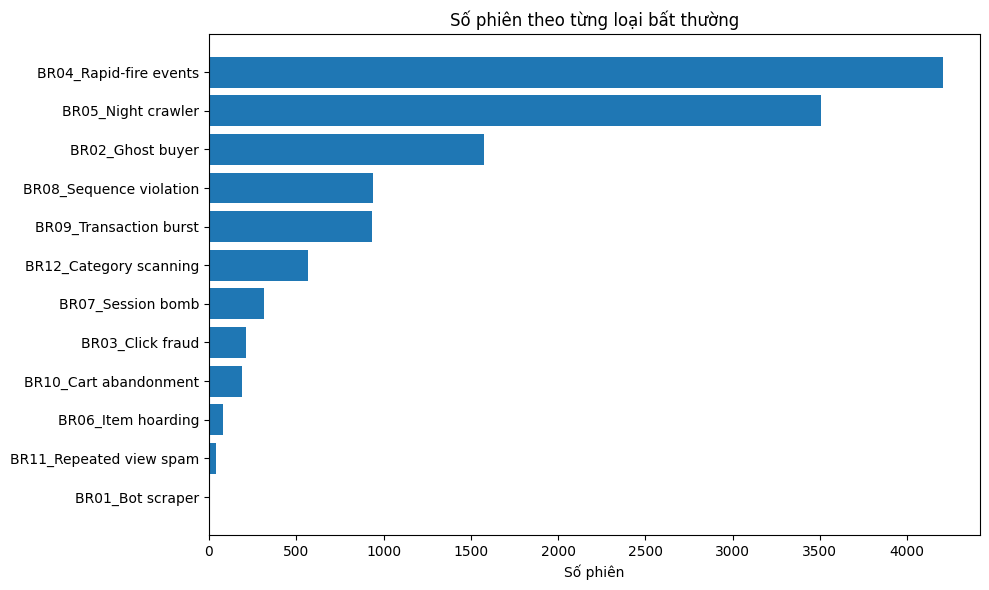

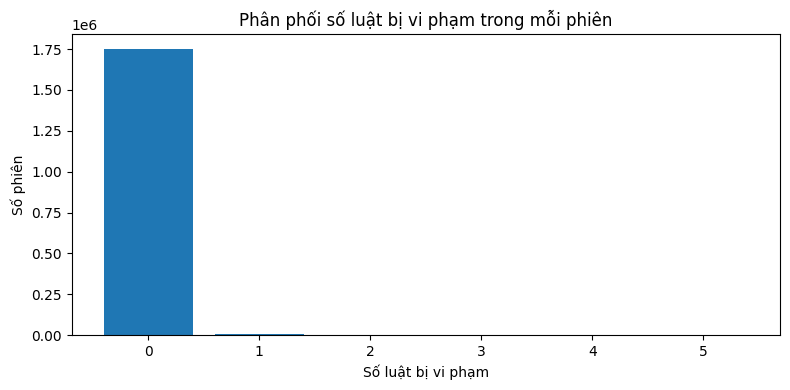

In [15]:
rule_summary = pd.DataFrame({
    "rule_code": [name.split("_")[0] for name in flag_name_map.values()],
    "anomaly_type": [name for name in flag_name_map.values()],
    "count": [int(anomalies[col].sum()) for col in flag_cols],
})
rule_summary["percent"] = rule_summary["count"] / len(anomalies) * 100
rule_summary = rule_summary.sort_values("count", ascending=False)

display(rule_summary)

fig, ax = plt.subplots(figsize=(10, 6))
plot_df = rule_summary.sort_values("count", ascending=True)
ax.barh(plot_df["anomaly_type"], plot_df["count"])
ax.set_title("Số phiên theo từng loại bất thường")
ax.set_xlabel("Số phiên")
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "02_rule_summary.png", dpi=160, bbox_inches="tight")
plt.show()

flag_distribution = anomalies["total_flags"].value_counts().sort_index()
plt.figure(figsize=(8, 4))
plt.bar(flag_distribution.index.astype(str), flag_distribution.values)
plt.title("Phân phối số luật bị vi phạm trong mỗi phiên")
plt.xlabel("Số luật bị vi phạm")
plt.ylabel("Số phiên")
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "03_total_flags_distribution.png", dpi=160, bbox_inches="tight")
plt.show()

## 16. Gán mức độ nghiêm trọng

Quy tắc gợi ý:

- `CRITICAL`: vi phạm từ 3 luật trở lên hoặc liên quan đến giao dịch bất thường.
- `HIGH`: vi phạm 2 luật.
- `MEDIUM`: vi phạm 1 luật.
- `LOW`: không vi phạm luật nào.

In [16]:
def classify_severity(row):
    if (
        row["total_flags"] >= 3 or
        row["flag_BR02_ghost_buyer"] == 1 or
        row["flag_BR08_sequence_violation"] == 1 or
        row["flag_BR09_transaction_burst"] == 1
    ):
        return "CRITICAL"
    if row["total_flags"] == 2:
        return "HIGH"
    if row["total_flags"] == 1:
        return "MEDIUM"
    return "LOW"

anomalies["severity"] = anomalies.apply(classify_severity, axis=1)
severity_summary = anomalies["severity"].value_counts().rename_axis("severity").reset_index(name="count")
severity_summary["percent"] = severity_summary["count"] / len(anomalies) * 100

display(severity_summary)

,severity,count,percent
0,LOW,1752163,99.460059
1,MEDIUM,6495,0.368683
2,CRITICAL,2412,0.136915
3,HIGH,605,0.034342


## 17. Kiểm tra rò rỉ nhãn và chọn đặc trưng huấn luyện

Không đưa các cột sau vào mô hình:

- Các cột `flag_BR...` vì đây là kết quả của luật.
- `is_anomaly_rule`, `anomaly_types`, `severity` vì đây là nhãn/diễn giải nhãn.
- `visitorid`, `session_id`, `session_start`, `session_end` vì đây là mã định danh hoặc thời gian thô.

Các mô hình sẽ học từ đặc trưng hành vi đã tổng hợp.

In [17]:
exclude_cols = set(group_cols + [
    "session_start", "session_end", "is_anomaly_rule", "anomaly_types", "severity", "total_flags"
] + flag_cols)

feature_cols = [
    col for col in anomalies.columns
    if col not in exclude_cols and pd.api.types.is_numeric_dtype(anomalies[col])
]

feature_audit = pd.DataFrame({"feature": feature_cols})
print("Số đặc trưng đưa vào mô hình:", len(feature_cols))
display(feature_audit)

X = anomalies[feature_cols].replace([np.inf, -np.inf], np.nan).fillna(0).astype("float32")
y = anomalies["is_anomaly_rule"].astype(int)

print("Tỉ lệ nhãn:")
display(y.value_counts(normalize=True).rename("ratio").reset_index().rename(columns={"index": "label"}))

Số đặc trưng đưa vào mô hình: 23


,feature
0,total_events
1,unique_items
2,active_hours
3,n_view
4,n_addtocart
5,n_transaction
6,night_events
7,min_interval_sec
8,mean_interval_sec
9,median_interval_sec


Tỉ lệ nhãn:


,is_anomaly_rule,ratio
0,0,0.994601
1,1,0.005399


## 18. Chia tập train/test và chuẩn hóa dữ liệu

Dữ liệu mất cân bằng mạnh, vì vậy cần dùng `stratify=y` khi chia tập và quan tâm nhiều hơn đến `precision`, `recall`, `F1-score`, `PR-AUC` thay vì chỉ nhìn `accuracy`.

In [18]:
all_indices = np.arange(len(y))

if MAX_SUPERVISED_ROWS is not None and len(y) > MAX_SUPERVISED_ROWS:
    trainable_indices, _ = train_test_split(
        all_indices,
        train_size=MAX_SUPERVISED_ROWS,
        random_state=RANDOM_STATE,
        stratify=y,
    )
else:
    trainable_indices = all_indices

X_model = X.iloc[trainable_indices]
y_model = y.iloc[trainable_indices]

X_train, X_test, y_train, y_test = train_test_split(
    X_model,
    y_model,
    test_size=0.25,
    random_state=RANDOM_STATE,
    stratify=y_model,
)

scaler = RobustScaler()
X_train_scaled = scaler.fit_transform(X_train).astype("float32")
X_test_scaled = scaler.transform(X_test).astype("float32")

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)
print("Train anomaly ratio:", y_train.mean())
print("Test anomaly ratio:", y_test.mean())

Train shape: (225000, 23)
Test shape: (75000, 23)
Train anomaly ratio: 0.0054
Test anomaly ratio: 0.0054


## 19. Hàm đánh giá mô hình

In [19]:
evaluation_records = []
confusion_matrices = {}
model_predictions = {}


def evaluate_model(model_name, y_true, y_pred, y_score=None):
    record = {
        "model": model_name,
        "accuracy": accuracy_score(y_true, y_pred),
        "precision": precision_score(y_true, y_pred, zero_division=0),
        "recall": recall_score(y_true, y_pred, zero_division=0),
        "f1_score": f1_score(y_true, y_pred, zero_division=0),
        "roc_auc": np.nan,
        "pr_auc": np.nan,
        "support_anomaly": int(np.sum(y_true)),
        "predicted_anomaly": int(np.sum(y_pred)),
    }

    if y_score is not None and len(np.unique(y_true)) == 2:
        try:
            record["roc_auc"] = roc_auc_score(y_true, y_score)
        except Exception:
            pass
        try:
            record["pr_auc"] = average_precision_score(y_true, y_score)
        except Exception:
            pass

    evaluation_records.append(record)
    confusion_matrices[model_name] = confusion_matrix(y_true, y_pred)
    print("=" * 80)
    print(model_name)
    print(classification_report(y_true, y_pred, zero_division=0))
    return record

## 20. Baseline và các mô hình có giám sát

In [20]:
# 1. Dummy baseline
baseline = DummyClassifier(strategy="stratified", random_state=RANDOM_STATE)
baseline.fit(X_train_scaled, y_train)
baseline_pred = baseline.predict(X_test_scaled)
baseline_score = baseline.predict_proba(X_test_scaled)[:, 1]
evaluate_model("Dummy baseline", y_test, baseline_pred, baseline_score)

# 2. Decision Tree
DecisionTree = DecisionTreeClassifier(
    max_depth=7,
    min_samples_leaf=30,
    class_weight="balanced",
    random_state=RANDOM_STATE,
)
DecisionTree.fit(X_train, y_train)
dt_pred = DecisionTree.predict(X_test)
dt_score = DecisionTree.predict_proba(X_test)[:, 1]
model_predictions["Decision Tree"] = dt_pred
evaluate_model("Decision Tree", y_test, dt_pred, dt_score)

# 3. Random Forest
RandomForest = RandomForestClassifier(
    n_estimators=200,
    max_depth=12,
    min_samples_leaf=10,
    class_weight="balanced_subsample",
    n_jobs=-1,
    random_state=RANDOM_STATE,
)
RandomForest.fit(X_train, y_train)
rf_pred = RandomForest.predict(X_test)
rf_score = RandomForest.predict_proba(X_test)[:, 1]
model_predictions["Random Forest"] = rf_pred
evaluate_model("Random Forest", y_test, rf_pred, rf_score)

# 4. XGBoost nếu môi trường có cài xgboost
if HAS_XGBOOST:
    pos = int(y_train.sum())
    neg = int(len(y_train) - pos)
    scale_pos_weight = neg / max(pos, 1)

    XGB = XGBClassifier(
        n_estimators=250,
        max_depth=5,
        learning_rate=0.08,
        subsample=0.9,
        colsample_bytree=0.9,
        objective="binary:logistic",
        eval_metric="logloss",
        scale_pos_weight=scale_pos_weight,
        random_state=RANDOM_STATE,
        n_jobs=-1,
    )
    XGB.fit(X_train, y_train)
    xgb_pred = XGB.predict(X_test)
    xgb_score = XGB.predict_proba(X_test)[:, 1]
    model_predictions["XGBoost"] = xgb_pred
    evaluate_model("XGBoost", y_test, xgb_pred, xgb_score)
else:
    print("Không có xgboost trong môi trường, bỏ qua mô hình XGBoost.")

Dummy baseline
              precision    recall  f1-score   support

           0       0.99      0.99      0.99     74595
           1       0.01      0.00      0.01       405

    accuracy                           0.99     75000
   macro avg       0.50      0.50      0.50     75000
weighted avg       0.99      0.99      0.99     75000

Decision Tree
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     74595
           1       0.68      0.98      0.80       405

    accuracy                           1.00     75000
   macro avg       0.84      0.99      0.90     75000
weighted avg       1.00      1.00      1.00     75000

Random Forest
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     74595
           1       0.73      0.98      0.84       405

    accuracy                           1.00     75000
   macro avg       0.87      0.99      0.92     75000
weighted avg       1.00      1.

## 21. Mô hình không giám sát: K-Means và Isolation Forest

K-Means và Isolation Forest không học trực tiếp từ nhãn luật. Vì vậy, các chỉ số dưới đây chỉ đo mức độ trùng khớp với nhãn tham chiếu `is_anomaly_rule`, không khẳng định mô hình sai hoàn toàn nếu kết quả thấp.

In [21]:
contamination = float(np.clip(y_train.mean(), 0.005, 0.05))

if MAX_UNSUPERVISED_ROWS is not None and len(X_train_scaled) > MAX_UNSUPERVISED_ROWS:
    unsup_indices = np.random.default_rng(RANDOM_STATE).choice(
        len(X_train_scaled), size=MAX_UNSUPERVISED_ROWS, replace=False
    )
    X_unsup_train = X_train_scaled[unsup_indices]
else:
    X_unsup_train = X_train_scaled

# Isolation Forest
iso = IsolationForest(
    n_estimators=200,
    contamination=contamination,
    random_state=RANDOM_STATE,
    n_jobs=-1,
)
iso.fit(X_unsup_train)
iso_raw = iso.predict(X_test_scaled)
iso_pred = (iso_raw == -1).astype(int)
iso_score = -iso.decision_function(X_test_scaled)
model_predictions["Isolation Forest"] = iso_pred
evaluate_model("Isolation Forest", y_test, iso_pred, iso_score)

# K-Means: lấy nhóm điểm xa tâm cụm nhất làm bất thường
kmeans = KMeans(n_clusters=5, random_state=RANDOM_STATE, n_init=10)
kmeans.fit(X_unsup_train)

distances = kmeans.transform(X_test_scaled).min(axis=1)
cutoff = np.quantile(distances, 1 - contamination)
kmeans_pred = (distances >= cutoff).astype(int)
model_predictions["K-Means distance"] = kmeans_pred
evaluate_model("K-Means distance", y_test, kmeans_pred, distances)

Isolation Forest
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     74595
           1       0.42      0.44      0.43       405

    accuracy                           0.99     75000
   macro avg       0.71      0.72      0.71     75000
weighted avg       0.99      0.99      0.99     75000

K-Means distance
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     74595
           1       0.20      0.20      0.20       405

    accuracy                           0.99     75000
   macro avg       0.60      0.60      0.60     75000
weighted avg       0.99      0.99      0.99     75000



{'model': 'K-Means distance',
 'accuracy': 0.99136,
 'precision': 0.2,
 'recall': 0.2,
 'f1_score': 0.2,
 'roc_auc': 0.9331257597611464,
 'pr_auc': 0.16926022533042817,
 'support_anomaly': 405,
 'predicted_anomaly': 405}

## 22. So sánh kết quả mô hình

,model,accuracy,precision,recall,f1_score,roc_auc,pr_auc,support_anomaly,predicted_anomaly
3,XGBoost,0.999093,0.871965,0.975309,0.920746,0.999877,0.989675,405,453
2,Random Forest,0.997973,0.732965,0.982716,0.839662,0.999688,0.954493,405,543
1,Decision Tree,0.997387,0.679862,0.975309,0.801217,0.987571,0.964932,405,581
4,Isolation Forest,0.993707,0.421546,0.444444,0.432692,0.979779,0.407093,405,427
5,K-Means distance,0.991360,0.200000,0.200000,0.200000,0.933126,0.169260,405,405
0,Dummy baseline,0.989413,0.005089,0.004938,0.005013,0.499848,0.005398,405,393


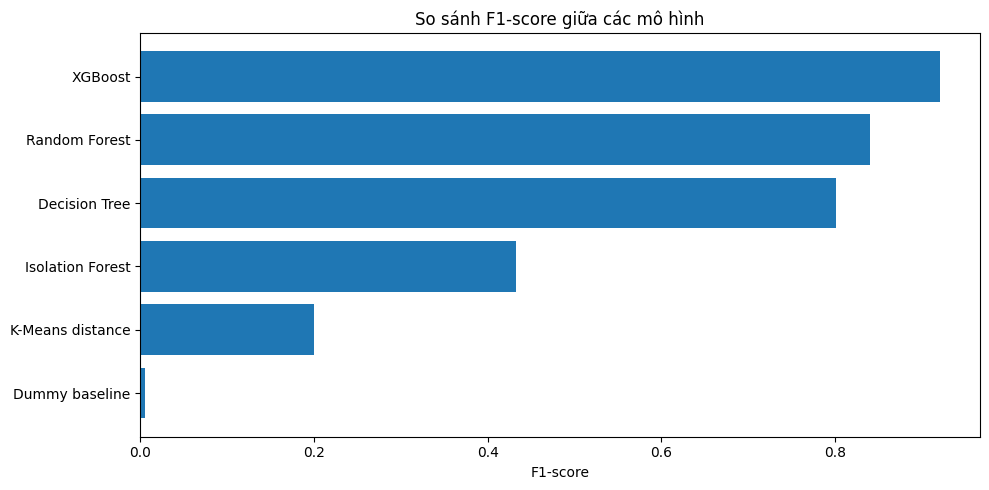

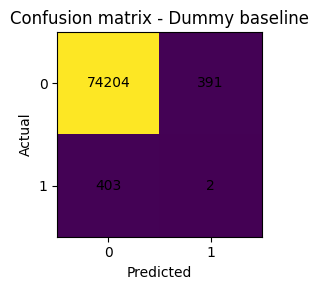

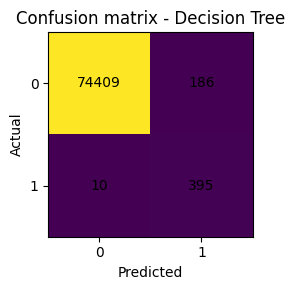

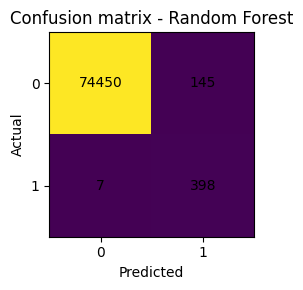

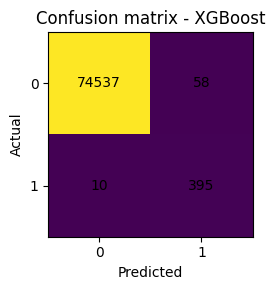

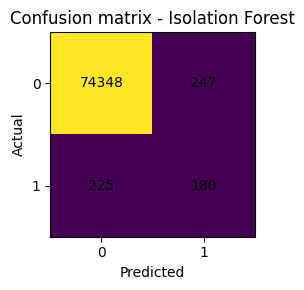

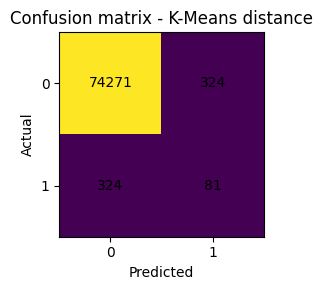

In [22]:
eval_df = pd.DataFrame(evaluation_records).sort_values(["f1_score", "pr_auc"], ascending=False)
display(eval_df)

eval_df.to_csv(OUTPUT_DIR / "model_evaluation_summary.csv", index=False)

fig, ax = plt.subplots(figsize=(10, 5))
plot_df = eval_df.sort_values("f1_score", ascending=True)
ax.barh(plot_df["model"], plot_df["f1_score"])
ax.set_title("So sánh F1-score giữa các mô hình")
ax.set_xlabel("F1-score")
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "04_model_f1_comparison.png", dpi=160, bbox_inches="tight")
plt.show()

for model_name, cm in confusion_matrices.items():
    fig, ax = plt.subplots(figsize=(4, 3))
    im = ax.imshow(cm)
    ax.set_title(f"Confusion matrix - {model_name}")
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Actual")
    ax.set_xticks([0, 1])
    ax.set_yticks([0, 1])
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            ax.text(j, i, cm[i, j], ha="center", va="center")
    plt.tight_layout()
    plt.show()

## 23. Feature importance

Phần này giúp giải thích mô hình học dựa trên những đặc trưng nào.

,model,feature,importance
23,Decision Tree,total_events,0.767262
46,XGBoost,total_events,0.484084
49,XGBoost,n_view,0.208076
0,Random Forest,total_events,0.193916
38,Decision Tree,buy_rate,0.180156
51,XGBoost,n_transaction,0.132834
3,Random Forest,n_view,0.118502
1,Random Forest,unique_items,0.096012
10,Random Forest,max_interval_sec,0.094316
59,XGBoost,view_rate,0.082763


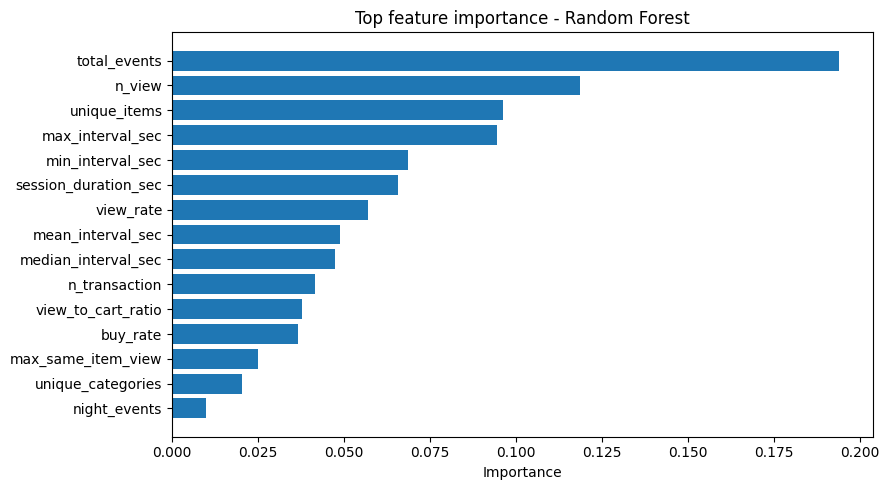

In [23]:
importance_records = []

if "RandomForest" in globals():
    for feature, importance in zip(feature_cols, RandomForest.feature_importances_):
        importance_records.append({"model": "Random Forest", "feature": feature, "importance": importance})

if "DecisionTree" in globals():
    for feature, importance in zip(feature_cols, DecisionTree.feature_importances_):
        importance_records.append({"model": "Decision Tree", "feature": feature, "importance": importance})

if HAS_XGBOOST and "XGB" in globals():
    for feature, importance in zip(feature_cols, XGB.feature_importances_):
        importance_records.append({"model": "XGBoost", "feature": feature, "importance": importance})

importance_df = pd.DataFrame(importance_records)
if len(importance_df) > 0:
    display(importance_df.sort_values("importance", ascending=False).head(20))
    importance_df.to_csv(OUTPUT_DIR / "feature_importance.csv", index=False)

    rf_top = importance_df[importance_df["model"] == "Random Forest"].sort_values("importance", ascending=False).head(15)
    if len(rf_top) > 0:
        plt.figure(figsize=(9, 5))
        plt.barh(rf_top["feature"][::-1], rf_top["importance"][::-1])
        plt.title("Top feature importance - Random Forest")
        plt.xlabel("Importance")
        plt.tight_layout()
        plt.savefig(OUTPUT_DIR / "05_random_forest_feature_importance.png", dpi=160, bbox_inches="tight")
        plt.show()

## 24. Tạo cảnh báo cuối cùng bằng kết hợp luật và mô hình

`is_anomaly_final` được tạo theo nguyên tắc thận trọng:

- Nếu phiên vi phạm luật nghiệp vụ thì đánh dấu bất thường.
- Hoặc nếu ít nhất 2 mô hình cùng cảnh báo thì đánh dấu bất thường.

Cách này giúp giảm rủi ro so với việc chỉ cần một mô hình bất kỳ cảnh báo là gắn nhãn bất thường.

In [24]:
# Huấn luyện lại một số mô hình chính trên toàn bộ tập mẫu để dự đoán cho toàn bộ session_features.
X_all_scaled = scaler.transform(X).astype("float32")

full_model_votes = pd.DataFrame(index=anomalies.index)

try:
    rf_all_pred = RandomForest.predict(X)
    full_model_votes["vote_random_forest"] = rf_all_pred
except Exception:
    pass

try:
    dt_all_pred = DecisionTree.predict(X)
    full_model_votes["vote_decision_tree"] = dt_all_pred
except Exception:
    pass

if HAS_XGBOOST and "XGB" in globals():
    try:
        xgb_all_pred = XGB.predict(X)
        full_model_votes["vote_xgboost"] = xgb_all_pred
    except Exception:
        pass

try:
    iso_all_pred = (iso.predict(X_all_scaled) == -1).astype(int)
    full_model_votes["vote_isolation_forest"] = iso_all_pred
except Exception:
    pass

if len(full_model_votes.columns) > 0:
    anomalies["model_vote_count"] = full_model_votes.sum(axis=1)
else:
    anomalies["model_vote_count"] = 0

anomalies["is_anomaly_final"] = (
    (anomalies["is_anomaly_rule"] == 1) |
    (anomalies["model_vote_count"] >= 2)
).astype(int)

print("Số phiên bất thường theo luật:", f"{anomalies['is_anomaly_rule'].sum():,}")
print("Số phiên bất thường cuối cùng:", f"{anomalies['is_anomaly_final'].sum():,}")
print("Tỉ lệ bất thường cuối cùng:", f"{anomalies['is_anomaly_final'].mean() * 100:.4f}%")

Số phiên bất thường theo luật: 9,512
Số phiên bất thường cuối cùng: 13,080
Tỉ lệ bất thường cuối cùng: 0.7425%


## 25. Phân tích ví dụ các phiên bất thường

In [25]:
example_cols = [
    "visitorid", "session_id", "severity", "anomaly_types", "total_events", "unique_items",
    "n_view", "n_addtocart", "n_transaction", "events_per_minute", "min_interval_sec",
    "night_ratio", "max_same_item_view", "max_same_item_atc", "model_vote_count"
]

severity_order = {"CRITICAL": 3, "HIGH": 2, "MEDIUM": 1, "LOW": 0}
anomalies["severity_rank"] = anomalies["severity"].map(severity_order)

anomaly_examples = (
    anomalies[anomalies["is_anomaly_final"] == 1]
    .sort_values(["severity_rank", "total_flags", "model_vote_count", "total_events"], ascending=False)
    [example_cols]
    .head(20)
)

display(anomaly_examples)
anomaly_examples.to_csv(OUTPUT_DIR / "anomaly_examples.csv", index=False)

,visitorid,session_id,severity,anomaly_types,total_events,unique_items,n_view,n_addtocart,n_transaction,events_per_minute,min_interval_sec,night_ratio,max_same_item_view,max_same_item_atc,model_vote_count
957442,765630,14,CRITICAL,"BR02_Ghost buyer, BR04_Rapid-fire events, BR07...",237,173,228,4,5,0.480585,0.002,0.000000,5.0,2.0,4
465356,371606,40,CRITICAL,"BR02_Ghost buyer, BR04_Rapid-fire events, BR07...",118,87,110,4,4,0.408776,0.016,0.000000,3.0,1.0,4
1439549,1150086,30,CRITICAL,"BR02_Ghost buyer, BR04_Rapid-fire events, BR07...",118,66,93,14,11,0.293201,0.125,0.135593,3.0,2.0,4
205003,163561,29,CRITICAL,"BR02_Ghost buyer, BR04_Rapid-fire events, BR07...",91,61,77,7,7,0.396209,0.109,0.153846,3.0,1.0,4
244660,195216,1,CRITICAL,"BR03_Click fraud, BR04_Rapid-fire events, BR05...",84,84,84,0,0,0.822057,0.078,1.000000,1.0,0.0,4
1116015,892013,8,CRITICAL,"BR03_Click fraud, BR04_Rapid-fire events, BR05...",80,78,80,0,0,2.560612,0.971,0.825000,2.0,0.0,4
957443,765630,15,CRITICAL,"BR03_Click fraud, BR04_Rapid-fire events, BR05...",68,53,68,0,0,0.354103,0.188,0.867647,3.0,0.0,4
248523,198270,6,CRITICAL,"BR02_Ghost buyer, BR04_Rapid-fire events, BR07...",64,54,62,0,2,0.276192,0.016,0.000000,3.0,0.0,4
1642955,1313381,27,CRITICAL,"BR03_Click fraud, BR04_Rapid-fire events, BR07...",330,157,330,0,0,2.445633,0.015,0.000000,12.0,0.0,4
662588,530033,1,CRITICAL,"BR04_Rapid-fire events, BR07_Session bomb, BR0...",310,206,300,5,5,0.425004,0.016,0.093548,7.0,1.0,4


## 26. Xuất kết quả

In [26]:
output_cols = group_cols + [
    "session_start", "session_end", "session_duration_sec", "total_events", "unique_items",
    "n_view", "n_addtocart", "n_transaction", "events_per_minute", "night_ratio",
    "is_anomaly_rule", "is_anomaly_final", "anomaly_types", "severity", "model_vote_count"
] + flag_cols

final_anomaly_result = anomalies[output_cols].copy()
final_anomaly_result.to_csv(OUTPUT_DIR / "final_session_anomaly_result.csv", index=False)
rule_summary.to_csv(OUTPUT_DIR / "rule_summary.csv", index=False)
threshold_df.to_csv(OUTPUT_DIR / "thresholds.csv", index=False)

print("Đã xuất các file:")
print(OUTPUT_DIR / "final_session_anomaly_result.csv")
print(OUTPUT_DIR / "rule_summary.csv")
print(OUTPUT_DIR / "thresholds.csv")
print(OUTPUT_DIR / "model_evaluation_summary.csv")

Đã xuất các file:
outputs/final_session_anomaly_result.csv
outputs/rule_summary.csv
outputs/thresholds.csv
outputs/model_evaluation_summary.csv


## 27. Kết luận và hạn chế

Notebook đã xây dựng quy trình phát hiện hành vi bất thường trong dữ liệu RetailRocket theo đơn vị phiên truy cập. Từ dữ liệu sự kiện ban đầu, notebook chuyển đổi thời gian, tạo phiên, trích xuất đặc trưng hành vi, xây dựng nhãn bất thường theo luật nghiệp vụ và huấn luyện các mô hình học máy để phân loại phiên bình thường/bất thường.

Điểm cải thiện chính so với cách gom theo `visitorid` là phân tích theo `session_id`, giúp phản ánh đúng hơn hành vi xảy ra trong từng lần truy cập. Các luật như `Bot scraper`, `Rapid-fire events`, `Session bomb`, `Ghost buyer` và `Sequence violation` cũng được định nghĩa chặt hơn theo chuỗi hành vi trong phiên.

Hạn chế quan trọng là RetailRocket không có nhãn gian lận hoặc nhãn bất thường thật. Vì vậy, nhãn `is_anomaly_rule` chỉ là nhãn tham chiếu được tạo từ luật nghiệp vụ. Kết quả mô hình cần được hiểu là khả năng học theo nhãn luật, không phải bằng chứng tuyệt đối về gian lận thực tế. Trong triển khai thật, các phiên bị cảnh báo nên được kiểm tra thêm bởi chuyên gia nghiệp vụ hoặc kết hợp thêm dữ liệu như thiết bị, địa chỉ IP, trạng thái thanh toán và lịch sử hoàn/hủy đơn.